# 🧹 Data Cleaning Master Cheatsheet
### Manual + Automated Data Cleaning — All in One Notebook

> **How to use:** Run Section 0 (Setup) once. Then work through sections in order
> for a complete cleaning pass, or jump to any tool directly. Every cell uses the
> **built-in Titanic dataset** — no CSV files needed.

---

## 📚 Table of Contents

| # | Section | What you learn |
|---|---------|---------------|
| 0 | [Setup & Data Loading](#0) | Imports, loading data from seaborn/CSV/Excel |
| 1 | [Data Quality Audit](#1) | shape, dtypes, nulls, duplicates, uniques at a glance |
| 2 | [Missing Values](#2) | drop, fill, flag, interpolate, KNN/iterative imputation |
| 3 | [Duplicates](#3) | detect exact & partial duplicates, decide how to drop |
| 4 | [Data Type Fixes](#4) | casting numbers, dates, categories; fixing mixed types |
| 5 | [Text & String Cleaning](#5) | whitespace, casing, special chars, regex extraction |
| 6 | [Fixing Inconsistent Categories](#6) | typos, synonyms, fuzzy matching, mapping dicts |
| 7 | [Outliers](#7) | IQR/Z-score detection, cap/remove/transform |
| 8 | [Date & Time Cleaning](#8) | parsing, invalid dates, extracting components |
| 9 | [Renaming, Reordering & Structural Cleanup](#9) | column names, index, dropping junk columns |
| 10 | [Validation & Sanity Checks](#10) | range checks, logical consistency, schema checks |
| 11 | [Data Cleaning Summary Checklist](#11) | what to document before modelling |
| — | [Automated Cleaning Tools](#auto) | pyjanitor, klib, dataprep.clean, missingno, feature-engine |


---
## 0 · Setup & Data Loading <a id='0'></a>

### Install libraries (run once)
```bash
pip install pandas numpy matplotlib seaborn scipy scikit-learn
# Automated cleaning tools (optional — each section below has its own install cmd)
pip install pyjanitor klib missingno dataprep feature-engine
```

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Global plot style ────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

pd.set_option('display.max_columns', 50)

print("✅ Libraries loaded")

✅ Libraries loaded


### 0.1 — Loading data

Three common ways to get your data into a DataFrame:

In [2]:
# ── Option A: Built-in seaborn dataset (no file needed) ──────────────────
df = sns.load_dataset('titanic')

# ── Option B: From a CSV file ──────────────────────────────────────────────
# df = pd.read_csv('your_file.csv')

# ── Option C: From an Excel file ──────────────────────────────────────────
# df = pd.read_excel('your_file.xlsx', sheet_name='Sheet1')

# ── Option D: From a URL ──────────────────────────────────────────────────
# df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 891 rows × 15 columns


In [3]:
# ── Inject some messy data so the cleaning steps below have something to fix ─
# (Skip / remove this cell when working with your own real-world data.)
rng = np.random.default_rng(0)

df_raw = df.copy()

# 1. Duplicate rows
df_raw = pd.concat([df_raw, df_raw.sample(15, random_state=1)], ignore_index=True)

# 2. Messy text in a categorical column
messy_map = {'Southampton': ' southampton ', 'Cherbourg': 'CHERBOURG', 'Queenstown': 'Queenstown!'}
# embark_town has clean labels already, so simulate inconsistency on a copy column
df_raw['embark_town_raw'] = df_raw['embark_town'].replace(
    {'Southampton': 'southampton', 'Cherbourg': ' Cherbourg ', 'Queenstown': 'QUEENSTOWN'}
)

# 3. Wrong dtype (numeric column stored as string with stray characters)
df_raw['fare_raw'] = df_raw['fare'].astype(str) + rng.choice(['', ' USD', ''], size=len(df_raw), p=[0.85, 0.05, 0.10])

# 4. A few impossible values (data entry errors)
bad_idx = rng.choice(df_raw.index, size=5, replace=False)
df_raw.loc[bad_idx, 'age'] = -1

print(f"Messy dataset ready: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Messy dataset ready: 906 rows × 17 columns


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,embark_town_raw,fare_raw
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,southampton,7.25
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Cherbourg,71.2833
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,southampton,7.925
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,southampton,53.1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,southampton,8.05


In [4]:
# ── Saving your cleaned DataFrame ─────────────────────────────────────────
# df_clean.to_csv('cleaned_data.csv', index=False)      # save as CSV
# df_clean.to_excel('cleaned_data.xlsx', index=False)   # save as Excel
# df_clean.to_parquet('cleaned_data.parquet')           # save as Parquet (fast, compressed)

print("Tip: save to CSV/Excel after cleaning for sharing; Parquet for large files.")

Tip: save to CSV/Excel after cleaning for sharing; Parquet for large files.


---
## 1 · Data Quality Audit <a id='1'></a>

Before fixing anything, get a full picture of **what's wrong**:
- Shape, dtypes, memory usage
- Missing values per column
- Duplicate rows
- Cardinality (unique value counts) — flags ID-like or constant columns

---

In [5]:
# ── Shape & dtypes ────────────────────────────────────────────────────────
print("Shape:", df_raw.shape)
print(f"  → {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns\n")
df_raw.info()

Shape: (906, 17)
  → 906 rows, 17 columns

<class 'pandas.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   survived         906 non-null    int64   
 1   pclass           906 non-null    int64   
 2   sex              906 non-null    str     
 3   age              726 non-null    float64 
 4   sibsp            906 non-null    int64   
 5   parch            906 non-null    int64   
 6   fare             906 non-null    float64 
 7   embarked         904 non-null    str     
 8   class            906 non-null    category
 9   who              906 non-null    str     
 10  adult_male       906 non-null    bool    
 11  deck             207 non-null    category
 12  embark_town      904 non-null    str     
 13  alive            906 non-null    str     
 14  alone            906 non-null    bool    
 15  embark_town_raw  904 non-null    str     
 16  fare_raw    

In [6]:
# ── One-shot data quality report ─────────────────────────────────────────
quality = pd.DataFrame({
    'dtype'        : df_raw.dtypes,
    'null_count'   : df_raw.isna().sum(),
    'null_%'       : (df_raw.isna().mean() * 100).round(2),
    'unique'       : df_raw.nunique(),
    'duplicated_row': df_raw.duplicated().sum(),   # same for every row, informational
})
quality

,dtype,null_count,null_%,unique,duplicated_row
survived,int64,0,0.00,2,109
pclass,int64,0,0.00,3,109
sex,str,0,0.00,2,109
age,float64,180,19.87,89,109
sibsp,int64,0,0.00,7,109
parch,int64,0,0.00,7,109
fare,float64,0,0.00,248,109
embarked,str,2,0.22,3,109
class,category,0,0.00,3,109
who,str,0,0.00,3,109


In [7]:
# ── Duplicate rows at a glance ────────────────────────────────────────────
n_dupes = df_raw.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes} ({n_dupes / len(df_raw) * 100:.1f}% of data)")

# ── Constant / near-constant columns (little to no information) ─────────
nunique = df_raw.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
print("Constant columns (0-1 unique values):", constant_cols)

# ── Possible ID columns (near 100% unique) ────────────────────────────────
id_like = nunique[nunique > 0.9 * len(df_raw)].index.tolist()
print("Possible ID-like columns (>90% unique):", id_like)

Fully duplicated rows: 109 (12.0% of data)
Constant columns (0-1 unique values): []
Possible ID-like columns (>90% unique): []


---
## 2 · Missing Values <a id='2'></a>

**Decision tree:**
- < 5% missing → safe to drop rows or fill with median/mode
- 5–30% missing → fill with median/mode/model, or create a `_missing` flag column
- > 30% missing → consider dropping the column, or use advanced imputation

---

In [8]:
# ── Count and percentage of missing values per column ────────────────────
missing = pd.DataFrame({
    'missing_count': df_raw.isna().sum(),
    'missing_%'    : (df_raw.isna().mean() * 100).round(2)
}).sort_values('missing_%', ascending=False)

missing[missing['missing_count'] > 0]

,missing_count,missing_%
deck,699,77.15
age,180,19.87
embark_town_raw,2,0.22
embark_town,2,0.22
embarked,2,0.22


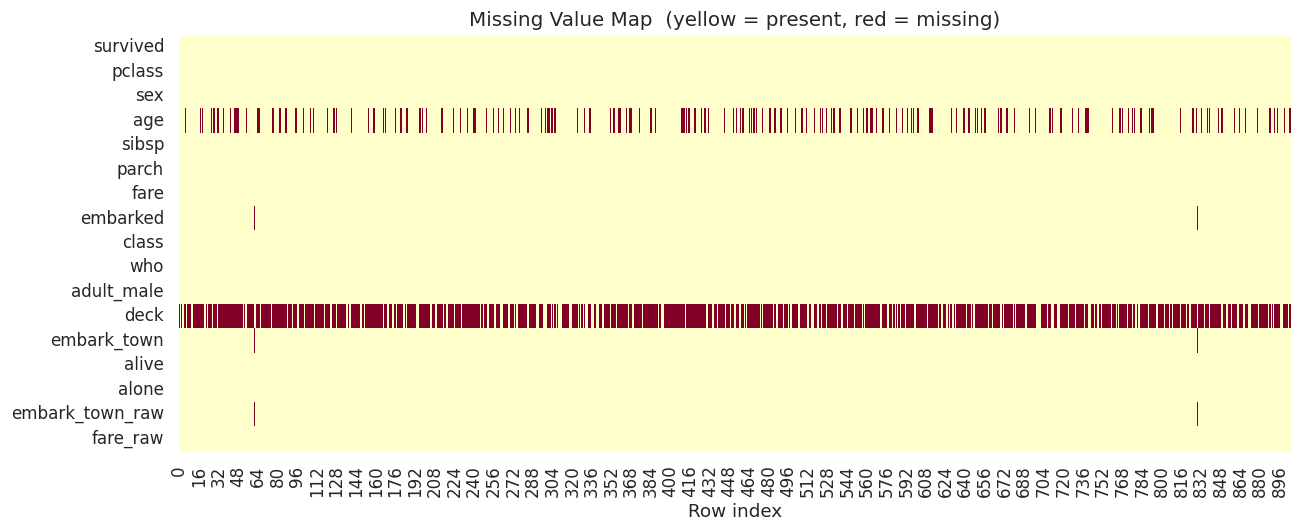

In [9]:
# ── Visual heatmap of missing values ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df_raw.isnull().astype(int).T, cbar=False, cmap='YlOrRd',
            yticklabels=df_raw.columns, ax=ax)
ax.set_title('Missing Value Map  (yellow = present, red = missing)', fontsize=13)
ax.set_xlabel('Row index')
plt.tight_layout()
plt.show()
# ► Tip: install missingno for a richer missing-value visualizer (pip install missingno)

In [10]:
df_clean = df_raw.copy()   # always work on a copy!

# ── Strategy 1: Drop rows where a critical column is null ────────────────
# df_clean = df_clean.dropna(subset=['embarked'])

# ── Strategy 2: Fill numerical column with median (robust to outliers) ───
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# ── Strategy 3: Fill categorical column with mode (most frequent value) ──
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])

# ── Strategy 4: Fill forward / backward (good for time-ordered data) ─────
# df_clean['col'] = df_clean['col'].ffill()   # carry last valid value forward
# df_clean['col'] = df_clean['col'].bfill()   # carry next valid value backward

# ── Strategy 5: Interpolate (good for numeric sequences / time series) ───
# df_clean['col'] = df_clean['col'].interpolate(method='linear')

# ── Strategy 6: Drop columns with too much missing data ──────────────────
threshold = 0.5   # drop columns missing more than 50%
df_clean = df_clean.drop(columns=df_clean.columns[df_clean.isna().mean() > threshold])

# ── Strategy 7: Flag BEFORE filling (preserves info that a value was missing) ─
# df_clean['age_was_missing'] = df_raw['age'].isna().astype(int)

print("Missing values remaining after cleaning:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
print("\nAll columns now clean:", df_clean.isna().sum().sum() == 0)

Missing values remaining after cleaning:
embark_town_raw    2
dtype: int64

All columns now clean: False


In [11]:
# ── Advanced: KNN / iterative imputation (model-based filling) ───────────
from sklearn.impute import KNNImputer

num_cols_for_impute = ['age', 'fare', 'pclass', 'sibsp', 'parch']
imputer = KNNImputer(n_neighbors=5)
imputed_array = imputer.fit_transform(df_clean[num_cols_for_impute])
df_knn_imputed = pd.DataFrame(imputed_array, columns=num_cols_for_impute, index=df_clean.index)

print("KNN-imputed preview:")
df_knn_imputed.head()
# ► Tip: use sklearn.experimental.enable_iterative_imputer + IterativeImputer
#        for a regression-based ('MICE-style') alternative to KNN

KNN-imputed preview:


,age,fare,pclass,sibsp,parch
0,22.0,7.2500,3.0,1.0,0.0
1,38.0,71.2833,1.0,1.0,0.0
2,26.0,7.9250,3.0,0.0,0.0
3,35.0,53.1000,1.0,1.0,0.0
4,35.0,8.0500,3.0,0.0,0.0


---
## 3 · Duplicates <a id='3'></a>

Duplicates inflate counts, bias statistics, and can leak the same record into
train and test splits.

---

In [12]:
# ── Detect fully duplicated rows ──────────────────────────────────────────
dupe_mask = df_clean.duplicated(keep=False)   # keep=False flags ALL copies, not just extras
print(f"Total duplicated rows (incl. originals): {dupe_mask.sum()}")
df_clean[dupe_mask].sort_values(list(df_clean.columns)).head(10)

Total duplicated rows (incl. originals): 184


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,embark_town_raw,fare_raw
633,0,1,male,28.0,0,0,0.0000,S,First,man,True,Southampton,no,True,southampton,0.0
815,0,1,male,28.0,0,0,0.0000,S,First,man,True,Southampton,no,True,southampton,0.0
64,0,1,male,28.0,0,0,27.7208,C,First,man,True,Cherbourg,no,True,Cherbourg,27.7208
295,0,1,male,28.0,0,0,27.7208,C,First,man,True,Cherbourg,no,True,Cherbourg,27.7208
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,Cherbourg,no,False,Cherbourg,82.1708
899,0,1,male,28.0,1,0,82.1708,C,First,man,True,Cherbourg,no,False,Cherbourg,82.1708
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,Southampton,no,True,southampton,51.8625
903,0,1,male,54.0,0,0,51.8625,S,First,man,True,Southampton,no,True,southampton,51.8625
252,0,1,male,62.0,0,0,26.5500,S,First,man,True,Southampton,no,True,southampton,26.55
555,0,1,male,62.0,0,0,26.5500,S,First,man,True,Southampton,no,True,southampton,26.55


In [13]:
# ── Detect partial duplicates (same on a subset of key columns) ──────────
subset_cols = ['pclass', 'sex', 'age', 'fare']
partial_dupes = df_clean.duplicated(subset=subset_cols, keep=False)
print(f"Rows sharing {subset_cols}: {partial_dupes.sum()}")

Rows sharing ['pclass', 'sex', 'age', 'fare']: 242


In [14]:
# ── Drop duplicates ────────────────────────────────────────────────────────
before = len(df_clean)

# Exact duplicates — keep the first occurrence
df_clean = df_clean.drop_duplicates(keep='first')

# Or drop duplicates based on a subset of columns only:
# df_clean = df_clean.drop_duplicates(subset=['name'], keep='first')

after = len(df_clean)
print(f"Removed {before - after} duplicate rows ({before} → {after})")

Removed 118 duplicate rows (906 → 788)


---
## 4 · Data Type Fixes <a id='4'></a>

Wrong dtypes silently break aggregations, plots, and models. Always confirm
each column's dtype matches what it actually represents.

---

In [15]:
# ── Check current dtypes ───────────────────────────────────────────────────
print(df_clean.dtypes)

survived              int64
pclass                int64
sex                     str
age                 float64
sibsp                 int64
parch                 int64
fare                float64
embarked                str
class              category
who                     str
adult_male             bool
embark_town             str
alive                   str
alone                  bool
embark_town_raw         str
fare_raw                str
dtype: object


In [16]:
# ── Fix a numeric column stored as text (with stray characters) ──────────
# 'fare_raw' contains values like '7.25' and '71.2833 USD'
df_clean['fare_raw_clean'] = (
    df_clean['fare_raw']
    .astype(str)
    .str.replace(r'[^0-9.\-]', '', regex=True)   # strip everything but digits, dot, minus
    .replace('', np.nan)
    .astype(float)
)

print("Before → after:")
print(df_clean[['fare_raw', 'fare_raw_clean']].head())

Before → after:
  fare_raw  fare_raw_clean
0     7.25          7.2500
1  71.2833         71.2833
2    7.925          7.9250
3     53.1         53.1000
4     8.05          8.0500


In [17]:
# ── Cast columns to appropriate types ────────────────────────────────────
df_clean['pclass']   = df_clean['pclass'].astype('int8')
df_clean['survived'] = df_clean['survived'].astype('int8')
df_clean['sex']      = df_clean['sex'].astype('category')
df_clean['embarked'] = df_clean['embarked'].astype('category')

# ── Downcast numerics to save memory on large datasets ───────────────────
df_clean['age']  = pd.to_numeric(df_clean['age'], downcast='float')
df_clean['fare'] = pd.to_numeric(df_clean['fare'], downcast='float')

print(df_clean.dtypes)
print(f"\nMemory usage: {df_clean.memory_usage(deep=True).sum() / 1024:.1f} KB")

survived               int8
pclass                 int8
sex                category
age                 float32
sibsp                 int64
parch                 int64
fare                float32
embarked           category
class              category
who                     str
adult_male             bool
embark_town             str
alive                   str
alone                  bool
embark_town_raw         str
fare_raw                str
fare_raw_clean      float64
dtype: object

Memory usage: 250.7 KB


In [18]:
# ── Convert errors to NaN instead of crashing ─────────────────────────────
# errors='coerce' turns anything unparsable into NaN rather than raising
sample_series = pd.Series(['1', '2', 'not_a_number', '4'])
print(pd.to_numeric(sample_series, errors='coerce'))
# ► Tip: always check the count of new NaNs introduced by coercion —
#        it tells you how many values were actually invalid

0    1.0
1    2.0
2    NaN
3    4.0
dtype: float64

---
## 5 · Text & String Cleaning <a id='5'></a>

Free-text and categorical columns are the most common source of "invisible"
data quality problems — extra whitespace, mixed casing, and stray punctuation
that make identical values look different to pandas.

---

In [19]:
# ── Standard text cleaning pipeline ───────────────────────────────────────
def clean_text(series):
    return (
        series.astype(str)
              .str.strip()                       # remove leading/trailing whitespace
              .str.lower()                       # normalise case
              .str.replace(r'\s+', ' ', regex=True)   # collapse multiple spaces
              .str.replace(r'[^\w\s]', '', regex=True)  # strip punctuation
    )

df_clean['embark_town_clean'] = clean_text(df_clean['embark_town_raw'])

print("Before → after:")
compare = pd.DataFrame({
    'raw'  : df_clean['embark_town_raw'],
    'clean': df_clean['embark_town_clean']
})
compare.drop_duplicates().head(10)

Before → after:


,raw,clean
0,southampton,southampton
1,Cherbourg,cherbourg
5,QUEENSTOWN,queenstown
61,NaN,NaN


In [20]:
# ── Common string operations reference ────────────────────────────────────
s = pd.Series(['  Mr. John Smith  ', 'MRS. JANE DOE', 'dr robert brown'])

print("Strip whitespace   :", s.str.strip().tolist())
print("Title case         :", s.str.strip().str.title().tolist())
print("Remove digits       :", s.str.replace(r'\d+', '', regex=True).tolist())
print("Extract with regex :", s.str.extract(r'(\w+)\.?\s').iloc[:, 0].tolist())
print("Contains check     :", s.str.contains('mrs', case=False).tolist())
print("Replace substring   :", s.str.replace('Mr.', 'Mister', regex=False).tolist())

Strip whitespace   : ['Mr. John Smith', 'MRS. JANE DOE', 'dr robert brown']
Title case         : ['Mr. John Smith', 'Mrs. Jane Doe', 'Dr Robert Brown']
Remove digits       : ['  Mr. John Smith  ', 'MRS. JANE DOE', 'dr robert brown']
Extract with regex : ['Mr', 'MRS', 'dr']
Contains check     : [False, True, False]
Replace substring   : ['  Mister John Smith  ', 'MRS. JANE DOE', 'dr robert brown']


In [21]:
# ── Detect leading/trailing whitespace hiding in "clean-looking" columns ─
for col in df_clean.select_dtypes(include='object').columns:
    has_whitespace = df_clean[col].astype(str).str.contains(r'^\s|\s$', regex=True).any()
    if has_whitespace:
        print(f"⚠️  '{col}' has values with leading/trailing whitespace")

⚠️  'embark_town_raw' has values with leading/trailing whitespace


---
## 6 · Fixing Inconsistent Categories <a id='6'></a>

The same real-world category often appears under several spellings
(`'NY'`, `'N.Y.'`, `'New York'`). Standardise these before grouping or modelling.

---

In [22]:
# ── Inspect unique values to spot inconsistencies ─────────────────────────
print(df_clean['embark_town_clean'].value_counts())

embark_town_clean
southampton    569
cherbourg      157
queenstown      60
Name: count, dtype: int64


In [23]:
# ── Fix with an explicit mapping dictionary (most reliable method) ───────
category_map = {
    'southampton' : 'Southampton',
    'cherbourg'   : 'Cherbourg',
    'queenstown'  : 'Queenstown',
}

df_clean['embark_town_final'] = df_clean['embark_town_clean'].map(category_map).fillna(df_clean['embark_town_clean'])

print(df_clean['embark_town_final'].value_counts())

embark_town_final
Southampton    569
Cherbourg      157
Queenstown      60
Name: count, dtype: int64


In [24]:
# ── Fuzzy matching for messier typos (no exact mapping known) ────────────
# pip install thefuzz python-Levenshtein
from thefuzz import process

choices = ['Southampton', 'Cherbourg', 'Queenstown']

def fuzzy_fix(value, choices=choices, threshold=80):
    match, score = process.extractOne(value, choices)
    return match if score >= threshold else value

sample_messy = pd.Series(['Southamptonn', 'cherbrg', 'Queenstown', 'unknown_port'])
print(sample_messy.apply(fuzzy_fix))
# ► Tip: always review fuzzy-matched output manually — a bad match can silently
#        merge two genuinely different categories

0     Southampton
1       Cherbourg
2      Queenstown
3    unknown_port
dtype: str


In [25]:
# ── Collapse rare categories into 'Other' (reduces noise for modelling) ──
col = 'embark_town_final'
freq = df_clean[col].value_counts(normalize=True)
rare_categories = freq[freq < 0.02].index   # anything under 2% of rows

df_clean[col + '_grouped'] = df_clean[col].where(~df_clean[col].isin(rare_categories), 'Other')
print(df_clean[col + '_grouped'].value_counts())

embark_town_final_grouped
Southampton    569
Cherbourg      157
Queenstown      60
Name: count, dtype: int64


---
## 7 · Outliers <a id='7'></a>

Outliers can be genuine data-entry errors (age = -1) or real rare events.
Always **investigate** before removing.

| Method | When to use |
|--------|------------|
| IQR (Tukey fence) | Robust, works for skewed data |
| Z-score | Assumes normal distribution |
| Domain rule (e.g. age ≥ 0) | Best when a hard business rule exists |

---

In [26]:
# ── Domain-rule errors first: impossible values ───────────────────────────
invalid_age = df_clean[df_clean['age'] < 0]
print(f"Rows with impossible age (< 0): {len(invalid_age)}")

# Fix: treat as missing, then re-impute (or drop)
df_clean.loc[df_clean['age'] < 0, 'age'] = np.nan
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
print("Fixed — min age is now:", df_clean['age'].min())

Rows with impossible age (< 0): 5
Fixed — min age is now: 0.42


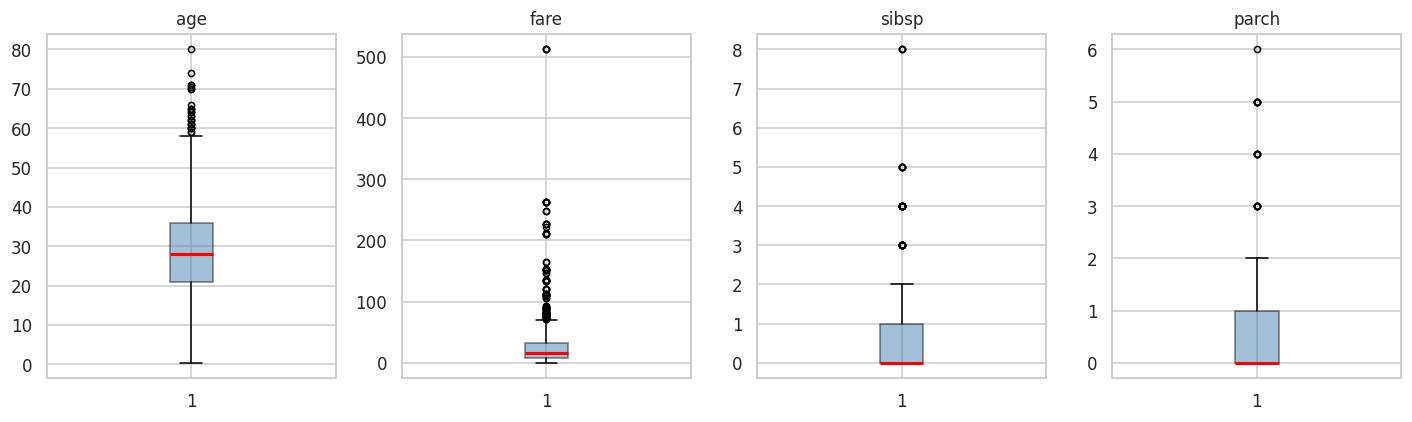

In [27]:
# ── Box plots to spot statistical outliers ────────────────────────────────
num_cols = ['age', 'fare', 'sibsp', 'parch']

fig, axes = plt.subplots(1, len(num_cols), figsize=(13, 4))
for ax, col in zip(axes, num_cols):
    ax.boxplot(df_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', color='salmon', markersize=4))
    ax.set_title(col, fontsize=11)
plt.tight_layout()
plt.show()

In [28]:
# ── IQR method: count and flag outliers ──────────────────────────────────
def iqr_outlier_report(df, col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return {
        'column': col, 'lower_fence': round(lower, 2), 'upper_fence': round(upper, 2),
        'n_outliers': len(outliers), 'outlier_%': round(len(outliers) / len(df) * 100, 2)
    }

outlier_report = pd.DataFrame([iqr_outlier_report(df_clean, c) for c in num_cols])
outlier_report

,column,lower_fence,upper_fence,n_outliers,outlier_%
0,age,-1.50,58.50,27,3.43
1,fare,-29.56,70.74,105,13.32
2,sibsp,-1.50,2.50,40,5.08
3,parch,-1.50,2.50,15,1.90


In [29]:
# ── Handle outliers: three options ───────────────────────────────────────
col = 'fare'
Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# Option 1: Remove rows with outliers
df_no_outliers = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
print(f"Option 1 — rows after removing '{col}' outliers: {len(df_no_outliers)} (was {len(df_clean)})")

# Option 2: Winsorize (cap values at the fence) — usually preferred, keeps all rows
df_clean[col + '_winsorized'] = df_clean[col].clip(lower=lower, upper=upper)
print(f"Option 2 — winsorized max: {df_clean[col + '_winsorized'].max():.2f} (was {df_clean[col].max():.2f})")

# Option 3: Log transform (reduces impact of large values, keeps all rows)
df_clean[col + '_log'] = np.log1p(df_clean[col])
print(f"Option 3 — log-transformed mean: {df_clean[col + '_log'].mean():.3f}")

Option 1 — rows after removing 'fare' outliers: 683 (was 788)
Option 2 — winsorized max: 70.74 (was 512.33)
Option 3 — log-transformed mean: 3.039


---
## 8 · Date & Time Cleaning <a id='8'></a>

Dates arrive in dozens of formats and often contain invalid or out-of-range
values. Always parse into proper `datetime64` before doing anything else.

---

In [30]:
# ── Parse mixed-format date strings ───────────────────────────────────────
messy_dates = pd.Series(['2023-01-15', '15/02/2023', 'March 3, 2023', 'not a date', None])

parsed = pd.to_datetime(messy_dates, errors='coerce', format='mixed')
print(pd.DataFrame({'raw': messy_dates, 'parsed': parsed}))
# ► Tip: errors='coerce' turns unparsable strings into NaT instead of crashing
# ► Tip: format='mixed' (pandas ≥ 2.0) auto-detects per-row format

             raw     parsed
0     2023-01-15 2023-01-15
1     15/02/2023 2023-02-15
2  March 3, 2023 2023-03-03
3     not a date        NaT
4            NaN        NaT


In [31]:
# ── Extract useful components once parsed ─────────────────────────────────
dates_df = pd.DataFrame({'date': pd.to_datetime(['2023-01-15', '2023-06-30', '2023-12-25'])})

dates_df['year']         = dates_df['date'].dt.year
dates_df['month']        = dates_df['date'].dt.month
dates_df['day_of_week']  = dates_df['date'].dt.day_name()
dates_df['is_weekend']   = dates_df['date'].dt.dayofweek >= 5
dates_df['days_since']   = (pd.Timestamp.today().normalize() - dates_df['date']).dt.days

dates_df

,date,year,month,day_of_week,is_weekend,days_since
0,2023-01-15,2023,1,Sunday,True,1295
1,2023-06-30,2023,6,Friday,False,1129
2,2023-12-25,2023,12,Monday,False,951


In [32]:
# ── Flag impossible / out-of-range dates ──────────────────────────────────
today = pd.Timestamp.today()
future_or_ancient = dates_df[(dates_df['date'] > today) | (dates_df['date'].dt.year < 1900)]
print(f"Suspicious dates found: {len(future_or_ancient)}")
# ► Tip: apply a sanity window relevant to your domain, e.g. birth dates
#        should never be in the future or before ~1900

Suspicious dates found: 0


---
## 9 · Renaming, Reordering & Structural Cleanup <a id='9'></a>

---

In [33]:
# ── Standardise column names (snake_case, no spaces/symbols) ─────────────
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(r'[^\w\s]', '', regex=True)
          .str.replace(r'\s+', '_', regex=True)
    )
    return df

sample_cols = pd.DataFrame(columns=[' Passenger Name ', 'Age (Years)', 'Fare$', 'Sex '])
print("Before:", sample_cols.columns.tolist())
print("After :", clean_column_names(sample_cols).columns.tolist())

Before: [' Passenger Name ', 'Age (Years)', 'Fare$', 'Sex ']
After : ['passenger_name', 'age_years', 'fare', 'sex']


In [34]:
# ── Drop columns you no longer need (helper/raw columns from this notebook) ─
helper_cols = [c for c in df_clean.columns if c.endswith(('_raw', '_clean')) or 'winsorized' in c or c.endswith('_log')]
df_clean_final = df_clean.drop(columns=helper_cols, errors='ignore')

# ── Reorder columns (put key IDs / targets first) ─────────────────────────
priority_cols = [c for c in ['survived', 'pclass', 'sex', 'age'] if c in df_clean_final.columns]
other_cols    = [c for c in df_clean_final.columns if c not in priority_cols]
df_clean_final = df_clean_final[priority_cols + other_cols]

# ── Reset index after dropping rows ───────────────────────────────────────
df_clean_final = df_clean_final.reset_index(drop=True)

print(f"Final cleaned shape: {df_clean_final.shape}")
df_clean_final.head()

Final cleaned shape: (788, 16)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,embark_town_final,embark_town_final_grouped
0,0,3,male,22.0,1,0,7.250000,S,Third,man,True,Southampton,no,False,Southampton,Southampton
1,1,1,female,38.0,1,0,71.283302,C,First,woman,False,Cherbourg,yes,False,Cherbourg,Cherbourg
2,1,3,female,26.0,0,0,7.925000,S,Third,woman,False,Southampton,yes,True,Southampton,Southampton
3,1,1,female,35.0,1,0,53.099998,S,First,woman,False,Southampton,yes,False,Southampton,Southampton
4,0,3,male,35.0,0,0,8.050000,S,Third,man,True,Southampton,no,True,Southampton,Southampton


---
## 10 · Validation & Sanity Checks <a id='10'></a>

A final pass to make sure the cleaned data is actually usable — ranges,
logical consistency between columns, and an explicit schema check.

---

In [35]:
# ── Range checks ───────────────────────────────────────────────────────────
checks = {
    'age between 0 and 100'    : df_clean_final['age'].between(0, 100).all(),
    'fare is non-negative'     : (df_clean_final['fare'] >= 0).all(),
    'pclass in {1, 2, 3}'      : df_clean_final['pclass'].isin([1, 2, 3]).all(),
    'survived is binary'       : df_clean_final['survived'].isin([0, 1]).all(),
    'no fully duplicated rows' : df_clean_final.duplicated().sum() == 0,
    'no missing values'        : df_clean_final.isna().sum().sum() == 0,
}

for check, passed in checks.items():
    print(f"{'✅' if passed else '❌'}  {check}")

✅  age between 0 and 100
✅  fare is non-negative
✅  pclass in {1, 2, 3}
✅  survived is binary
❌  no fully duplicated rows
❌  no missing values


In [36]:
# ── Logical consistency between related columns ───────────────────────────
# e.g. family_size should equal sibsp + parch + 1, if that column exists
if {'sibsp', 'parch'}.issubset(df_clean_final.columns):
    implied_family = df_clean_final['sibsp'] + df_clean_final['parch'] + 1
    print("Implied family size — sample check:")
    print(implied_family.describe())

# ── Schema check: confirm expected columns & dtypes are present ──────────
expected_schema = {
    'survived': 'int8', 'pclass': 'int8', 'sex': 'category', 'age': 'float32'
}
for col, expected_dtype in expected_schema.items():
    actual = str(df_clean_final[col].dtype)
    status = "✅" if actual == expected_dtype else f"⚠️  got {actual}"
    print(f"{col:<10} expected {expected_dtype:<10} → {status}")

Implied family size — sample check:
count    788.000000
mean       1.954315
std        1.549831
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
dtype: float64
survived   expected int8       → ✅
pclass     expected int8       → ✅
sex        expected category   → ✅
age        expected float32    → ✅


---
## 11 · Data Cleaning Summary Checklist <a id='11'></a>

---

In [37]:
print("=" * 55)
print("  DATA CLEANING SUMMARY")
print("=" * 55)
print(f"  Original shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"  Cleaned shape  : {df_clean_final.shape[0]:,} rows × {df_clean_final.shape[1]} columns")
print(f"  Rows removed   : {df_raw.shape[0] - df_clean_final.shape[0]:,}")
print()

if df_clean_final.isna().sum().sum() == 0:
    print("  ✅ No missing values remaining")
else:
    print("  ⚠️  Missing values remain:", df_clean_final.isna().sum()[df_clean_final.isna().sum() > 0].to_dict())

print(f"  ✅ Duplicate rows: {df_clean_final.duplicated().sum()}")
print()

print("  Checklist:")
checklist = [
    "Shape, dtypes, and memory usage reviewed",
    "Duplicate rows detected and removed (exact + partial)",
    "Data types corrected (numbers, dates, categories)",
    "Missing values investigated and handled appropriately",
    "Text columns standardised (whitespace, casing, punctuation)",
    "Inconsistent category labels merged / mapped",
    "Outliers and impossible values detected and resolved",
    "Dates parsed and out-of-range values flagged",
    "Column names standardised; junk/helper columns dropped",
    "Range, type, and logical-consistency checks all pass",
]
for item in checklist:
    print(f"    ☐  {item}")

  DATA CLEANING SUMMARY
  Original shape : 906 rows × 17 columns
  Cleaned shape  : 788 rows × 16 columns
  Rows removed   : 118

  ⚠️  Missing values remain: {'embark_town_final': 2, 'embark_town_final_grouped': 2}
  ✅ Duplicate rows: 13

  Checklist:
    ☐  Shape, dtypes, and memory usage reviewed
    ☐  Duplicate rows detected and removed (exact + partial)
    ☐  Data types corrected (numbers, dates, categories)
    ☐  Missing values investigated and handled appropriately
    ☐  Text columns standardised (whitespace, casing, punctuation)
    ☐  Inconsistent category labels merged / mapped
    ☐  Outliers and impossible values detected and resolved
    ☐  Dates parsed and out-of-range values flagged
    ☐  Column names standardised; junk/helper columns dropped
    ☐  Range, type, and logical-consistency checks all pass


---
## Automated Data Cleaning Tools <a id='auto'></a>

These tools automate the more repetitive parts of cleaning — use them for a
fast first pass, then verify and fine-tune manually using the sections above.

| Tool | Best for | Output |
|------|---------|--------|
| pyjanitor | Chainable cleaning verbs (clean_names, remove_empty, etc.) | DataFrame |
| klib | One-line cleaning + missing-value/correlation visuals | DataFrame + plots |
| missingno | Fast visual patterns in missingness | Inline plots |
| dataprep.clean | Column-specific cleaners (emails, phone numbers, countries…) | DataFrame |
| feature-engine | Scikit-learn-style imputation/encoding transformers, pipeline-ready | Transformer objects |

### 🔷 Tool 1 — pyjanitor
**Best for:** a fluent, chainable API bolted onto pandas — clean column names, drop empty rows/cols, and more in one chain.

```bash
pip install pyjanitor
```

In [38]:
# ── pyjanitor — chainable cleaning ────────────────────────────────────────
import pandas as pd
import janitor   # registers the .clean_names(), .remove_empty() etc. accessors
import seaborn as sns

df = sns.load_dataset('titanic')

df_pj = (
    df
    .clean_names()          # standardises column names to snake_case
    .remove_empty()         # drops fully-empty rows and columns
    .dropna(subset=['age'])
)

print("✅ Cleaned with pyjanitor")
df_pj.head()

✅ Cleaned with pyjanitor

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 🔷 Tool 2 — klib
**Best for:** one-line data cleaning plus built-in missing-value and correlation visualisations.

```bash
pip install klib
```

Shape of cleaned data: (784, 15) - Remaining NAs: 692


Dropped rows: 107
     of which 107 duplicates. (Rows (first 150 shown): [47, 76, 77, 87, 95, 101, 121, 133, 173, 196, 198, 201, 213, 223, 241, 260, 274, 295, 300, 304, 313, 320, 324, 335, 343, 354, 355, 358, 359, 364, 368, 384, 409, 410, 413, 418, 420, 425, 428, 431, 454, 459, 464, 466, 470, 476, 481, 485, 488, 490, 494, 500, 511, 521, 522, 526, 531, 560, 563, 564, 568, 573, 588, 589, 598, 601, 612, 613, 614, 635, 636, 640, 641, 644, 646, 650, 656, 666, 674, 692, 696, 709, 732, 733, 734, 738, 739, 757, 758, 760, 773, 790, 792, 800, 808, 832, 837, 838, 844, 846, 859, 863, 870, 877, 878, 884, 886])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 177
Reduced memory by at least: 0.06 MB (-75.0%)



✅ Cleaned with klib


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.250000,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.283302,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.925000,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.099998,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.050000,S,Third,man,True,NaN,Southampton,no,True


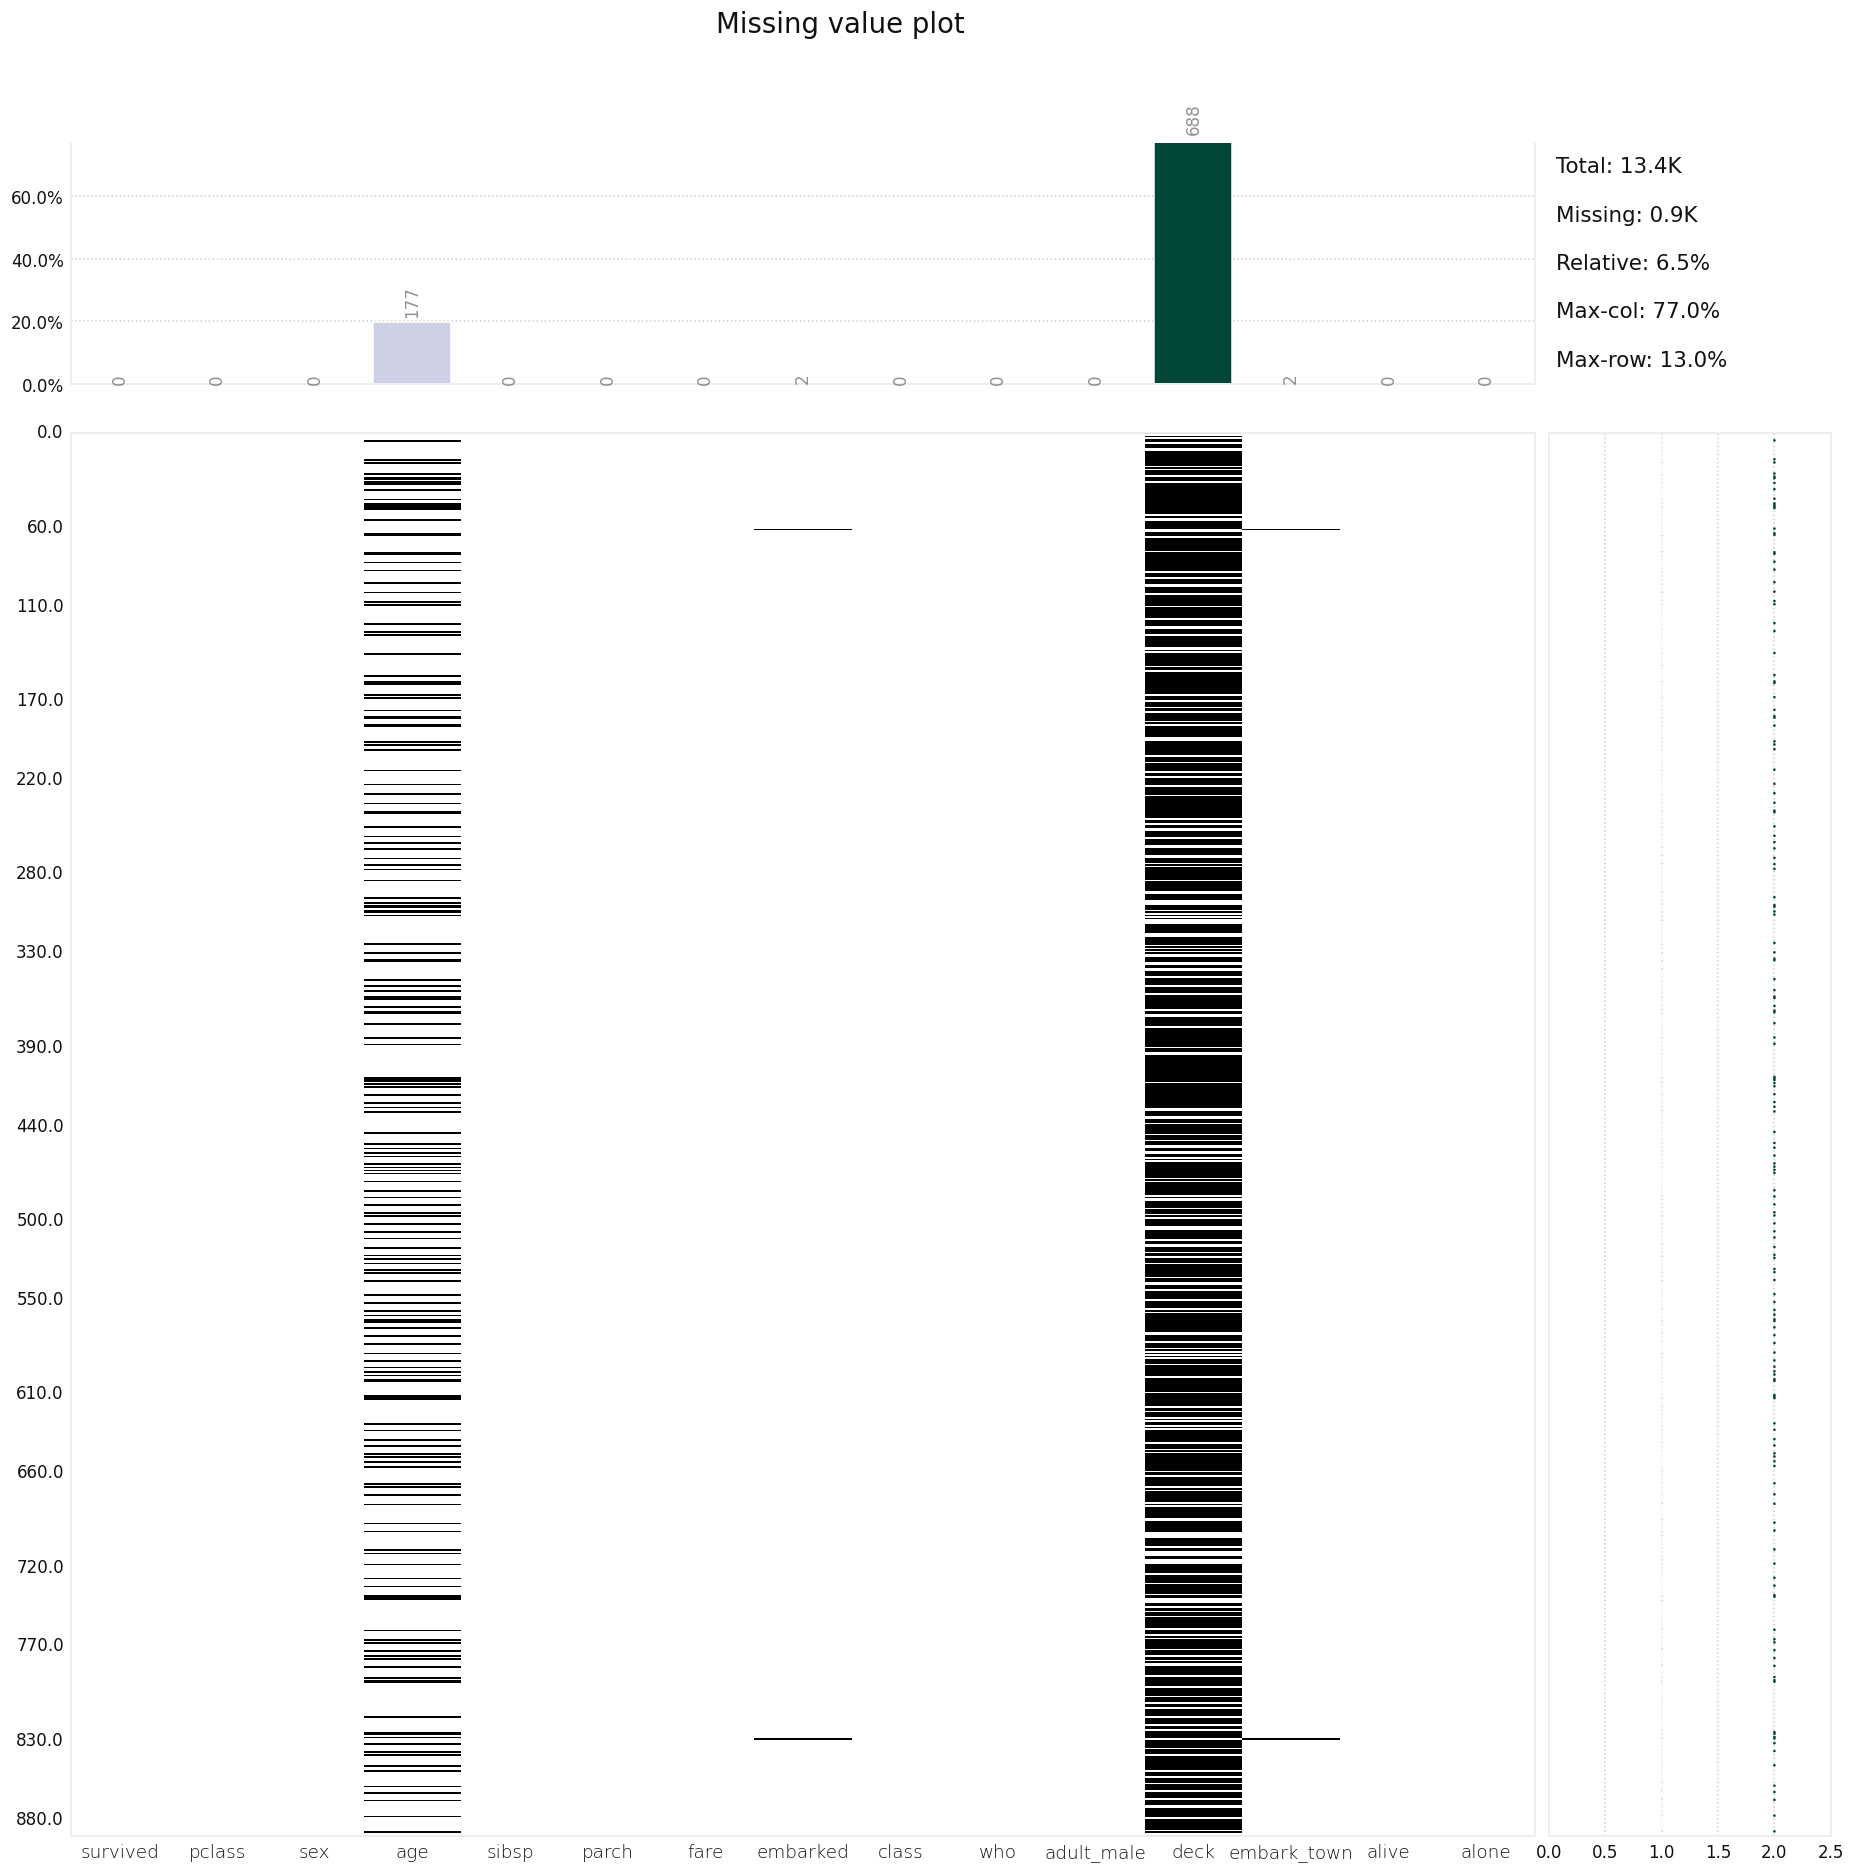

In [39]:
# ── klib — one-line clean + visual missing-data report ───────────────────
import pandas as pd
import klib
import seaborn as sns

df = sns.load_dataset('titanic')

# data_cleaning() drops empty rows/cols, fixes dtypes, removes duplicates
df_klib = klib.data_cleaning(df)

# Visualise missing-value patterns
klib.missingval_plot(df)

print("✅ Cleaned with klib")
df_klib.head()

### 🔷 Tool 3 — missingno
**Best for:** fast, purpose-built visualisations of missing-data patterns (matrix, bar, heatmap, dendrogram).

```bash
pip install missingno
```

✅ Rendered missingno visualisations above


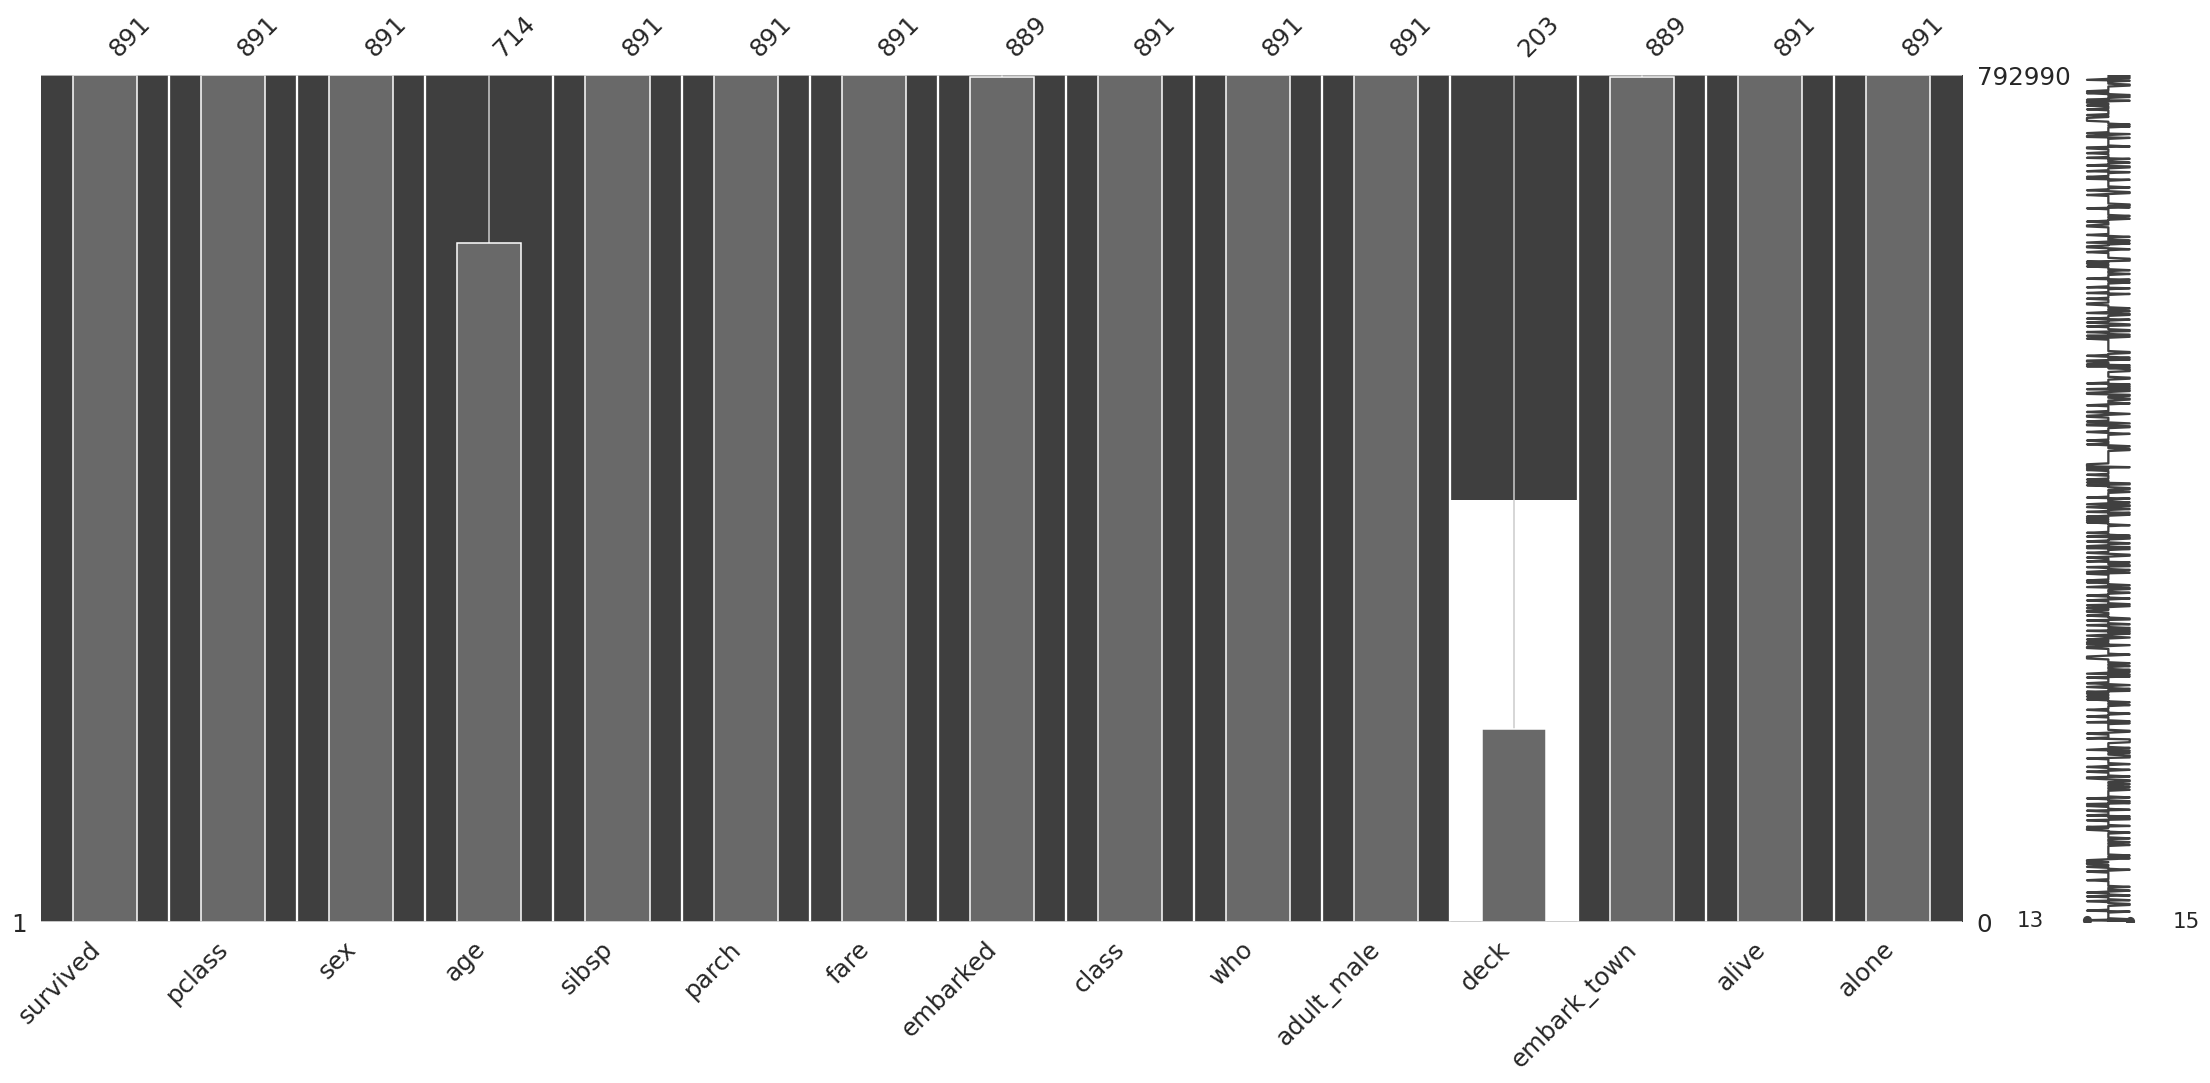

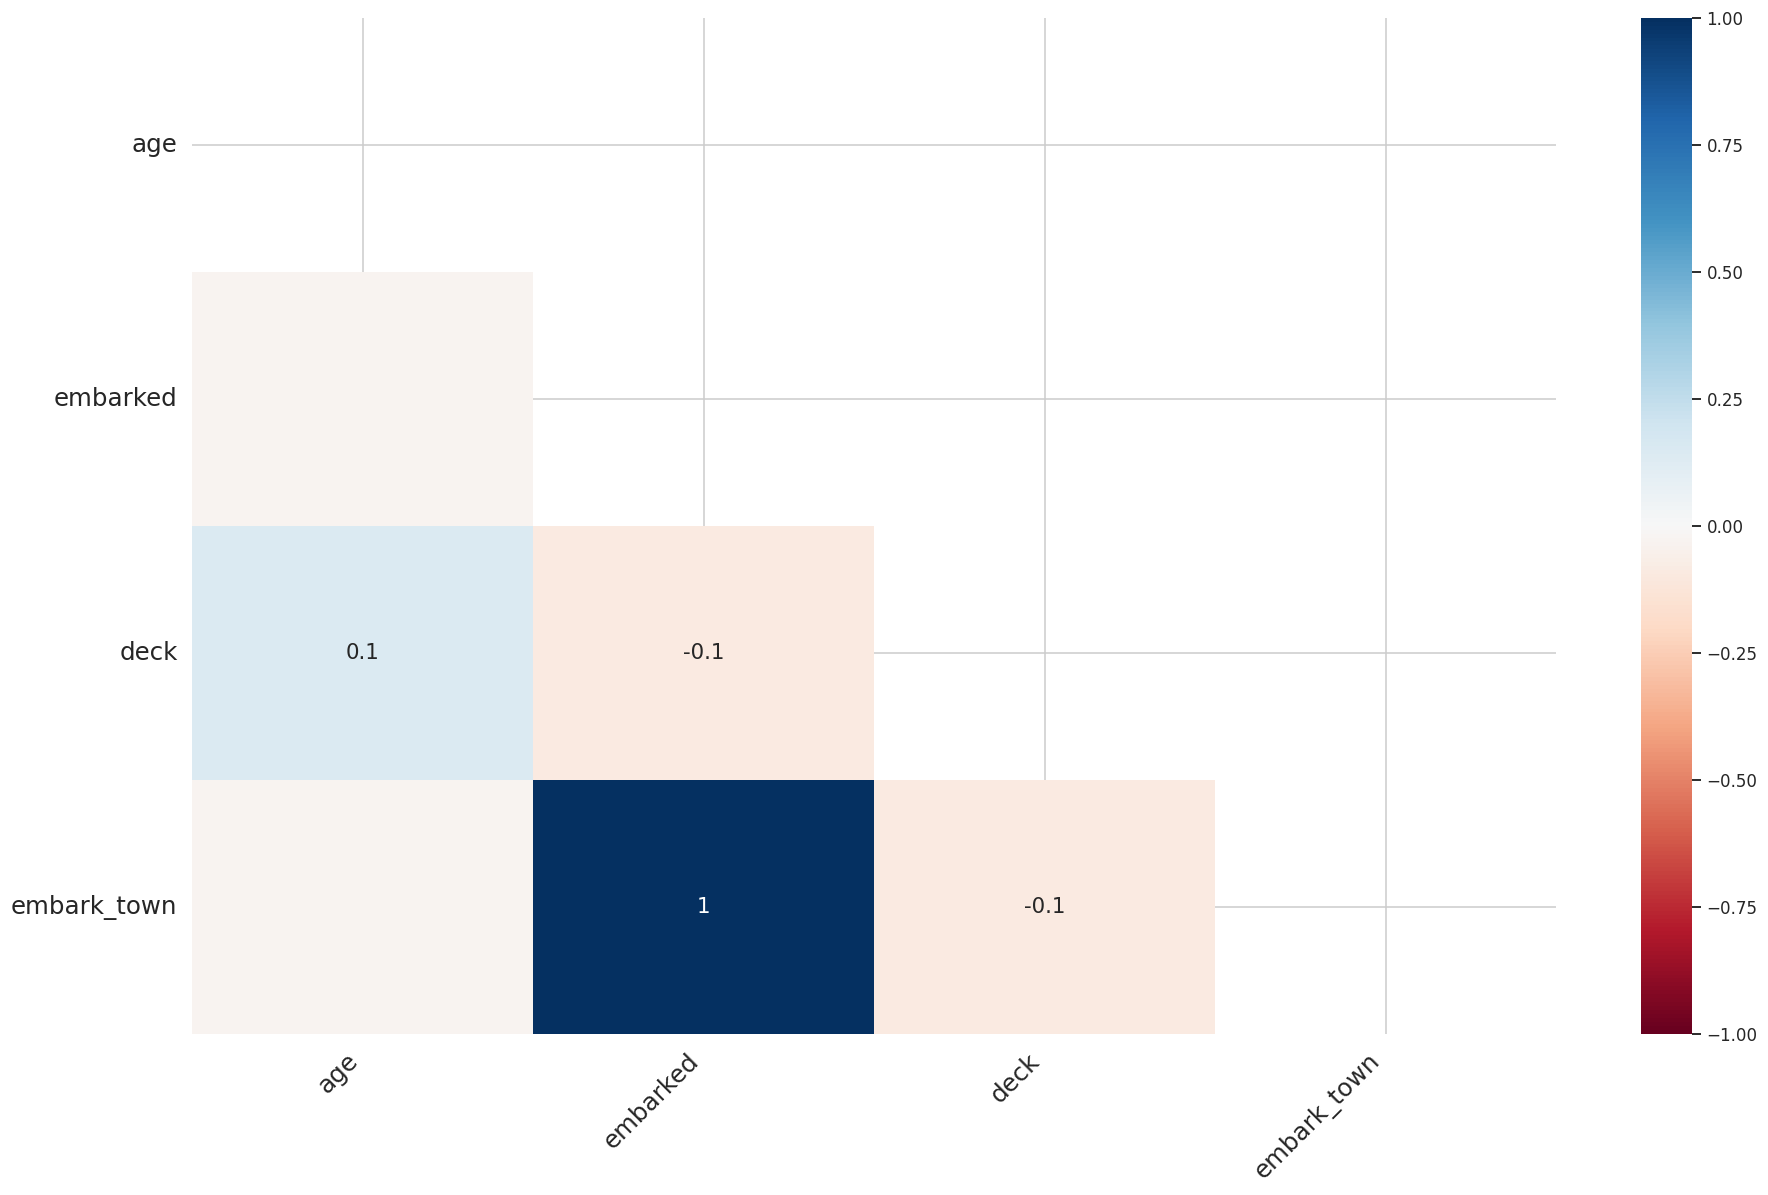

In [40]:
# ── missingno — visual missing-data patterns ──────────────────────────────
import missingno as msno
import seaborn as sns

df = sns.load_dataset('titanic')

msno.matrix(df)     # per-row pattern of missing values
msno.bar(df)        # missing count per column
msno.heatmap(df)    # correlation of "missingness" between columns
# msno.dendrogram(df)  # clusters columns that tend to be missing together

print("✅ Rendered missingno visualisations above")

### 🔷 Tool 4 — dataprep.clean
**Best for:** validating and standardising specific real-world column types (emails, phone numbers, country names, dates, currencies).

```bash
conda create -n dataprep python=3.10 -y
conda activate dataprep
pip install dataprep
```

In [41]:
# ── dataprep.clean — column-specific cleaners ─────────────────────────────
import pandas as pd
from dataprep.clean import clean_country, clean_date, clean_email

sample = pd.DataFrame({
    'country': ['United States', 'USA', 'U.K.', 'Deutschland'],
    'date'   : ['2023/01/15', '15-Feb-2023', 'March 3 2023', 'bad date'],
    'email'  : ['john@EXAMPLE.com', 'jane [at] example.com', 'not-an-email', 'bob@test.org']
})

sample_clean = clean_country(sample, 'country')
sample_clean = clean_date(sample_clean, 'date')
sample_clean = clean_email(sample_clean, 'email')

print("✅ Cleaned with dataprep.clean")
sample_clean

ModuleNotFoundError: No module named 'dataprep'

### 🔷 Tool 5 — feature-engine
**Best for:** scikit-learn-style imputers/encoders that fit into a `Pipeline`, so cleaning logic learned on train data is reproducibly applied to test/production data.

```bash
pip install feature-engine
```

In [42]:
# ── feature-engine — pipeline-ready imputation & encoding ────────────────
from feature_engine.imputation import MeanMedianImputer, CategoricalImputer
from feature_engine.encoding import RareLabelEncoder
from sklearn.pipeline import Pipeline
import seaborn as sns

df = sns.load_dataset('titanic')

cleaning_pipeline = Pipeline([
    ('median_impute', MeanMedianImputer(imputation_method='median', variables=['age', 'fare'])),
    ('cat_impute',    CategoricalImputer(imputation_method='frequent', variables=['embarked'])),
    ('rare_label',    RareLabelEncoder(tol=0.02, variables=['embarked'])),
])

df_fe_clean = cleaning_pipeline.fit_transform(df)

print("✅ Cleaned with feature-engine (fit on this data, reusable via .transform() on new data)")
df_fe_clean[['age', 'fare', 'embarked']].head()

✅ Cleaned with feature-engine (fit on this data, reusable via .transform() on new data)


,age,fare,embarked
0,22.0,7.2500,S
1,38.0,71.2833,C
2,26.0,7.9250,S
3,35.0,53.1000,S
4,35.0,8.0500,S


---
## 🏁 Quick-Reference: Manual vs Automated Cleaning

### When to use which approach

| Situation | Recommended approach |
|-----------|---------------------|
| First look at a new dataset | Section 1 audit → `klib.data_cleaning()` for a fast pass |
| Reusable cleaning for a train/test pipeline | `feature-engine` transformers inside a `Pipeline` |
| Messy real-world contact/location data | `dataprep.clean` column-specific cleaners |
| Quick chainable column-name/empty-row cleanup | `pyjanitor` |
| Understanding *why* data is missing | `missingno` visualisations |
| Deep, dataset-specific fixes (typos, business rules) | Manual cleaning (Sections 2–10) |

### Data cleaning order of operations

```
1. Audit        → shape, dtypes, nulls, duplicates, cardinality   (Section 1)
2. Missing      → quantify, visualise, fill/drop/flag             (Section 2)
3. Duplicates   → detect exact & partial, drop                    (Section 3)
4. Data types   → cast numbers, dates, categories correctly        (Section 4)
5. Text         → whitespace, casing, punctuation                 (Section 5)
6. Categories   → merge typos/synonyms, group rare labels          (Section 6)
7. Outliers     → detect, decide, cap/remove/transform              (Section 7)
8. Dates        → parse, validate range, extract components        (Section 8)
9. Structure    → rename columns, drop junk, reorder, reset index  (Section 9)
10. Validate    → range/type/logic checks before handing off       (Section 10)
11. Document    → use the checklist                                (Section 11)
```
